In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [2]:
df=pd.read_csv('kc_house_preprocessed.csv')
df

,price,bedrooms,bathrooms,Scaled_size,floors,waterfront,sqft_living,condition,Loc_Budget,Loc_Mid-Range,Loc_Premium
0,221900.0,3.0,1.00,0.225631,1.0,0,1180.0,3,0,0,1
1,538000.0,3.0,2.25,0.578020,2.0,0,2570.0,3,1,0,0
2,180000.0,2.0,1.00,0.121688,1.0,0,770.0,3,0,0,1
3,604000.0,4.0,3.00,0.423374,1.0,0,1960.0,5,0,0,1
4,510000.0,3.0,2.00,0.352389,1.0,0,1680.0,3,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,0.314362,3.0,0,1530.0,3,0,0,1
21609,400000.0,4.0,2.50,0.512105,2.0,0,2310.0,3,0,0,1
21610,402101.0,2.0,0.75,0.185068,2.0,0,1020.0,3,1,0,0
21611,400000.0,3.0,2.50,0.332108,2.0,0,1600.0,3,1,0,0


In [5]:
#separate features (X- our clues) from the target (y- what we want to predict)
x=df.drop(columns=['price'])
y=df['price']

#Perform the 80/20 train/test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

print(f"Training set has: {x_train.shape[0]} rows")
print(f"Testing set has: {x_test.shape[0]} rows")

Training set has: 17290 rows
Testing set has: 4323 rows


In [9]:
#Simple Linear Regression (select only 'Scaled_size' column for our simple model)
x_train_simple=x_train[['Scaled_size']]
x_test_simple=x_test[['Scaled_size']]

#1.Initialize the model
model=LinearRegression()

#2. Train the model (find the best-fit line)
model.fit(x_train_simple,y_train)

print("Simple Linear Regression model has been trained successfully")

Simple Linear Regression model has been trained successfully


In [10]:
#Predicting the prices of the test set
y_pred_simple=model.predict(x_test_simple)
y_pred_simple

array([513754.06569843, 686863.30569022, 868315.15965752, ...,
       589671.85287555, 551295.82858822, 618036.74039228], shape=(4323,))

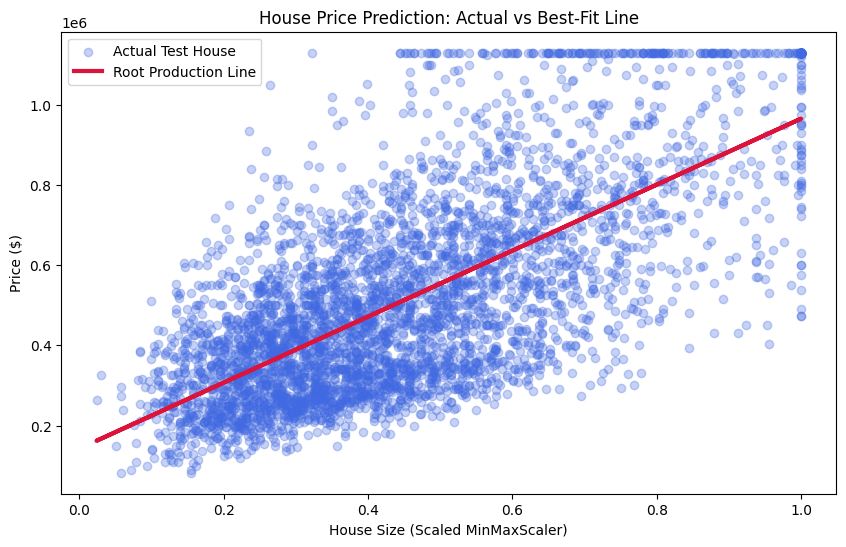

In [11]:
#Visualization of linear regression graph
plt.figure(figsize=(10,6))
plt.scatter(x_test_simple['Scaled_size'],y_test,color='royalblue',alpha=0.3,label='Actual Test House')
plt.plot(x_test_simple['Scaled_size'],y_pred_simple,color='crimson',linewidth=3,label='Root Production Line')
plt.xlabel('House Size (Scaled MinMaxScaler)')
plt.ylabel('Price ($)')
plt.title('House Price Prediction: Actual vs Best-Fit Line')
plt.legend()
plt.show()

In [12]:
#Multiple Linear Regression
multiple_model=LinearRegression()
#Train on all training features
multiple_model.fit(x_train,y_train)
#Predict the prices of the test set
y_pred_multiple=multiple_model.predict(x_test)
print(y_pred_simple)
print(y_pred_multiple)
print("Multiple Linear Regression Model has been trained and predictions made successfully")

[513754.06569843 686863.30569022 868315.15965752 ... 589671.85287555
 551295.82858822 618036.74039228]
[524128.18921278 691477.18843096 864395.59042167 ... 571036.9181263
 534453.70576409 600718.9874884 ]
Multiple Linear Regression Model has been trained and predictions made successfully


In [13]:
#Predicting price from a given data
custom_house=pd.DataFrame([{
    'bedrooms':3.0,
    'bathrooms':2.0,
    'Scaled_size':0.35,
    'floors':2.0,
    'waterfront':0,
    'sqft_living':1800.0,
    'condition':4,
    'Loc_Budget':0,
    'Loc_Mid-Range':1,
    'Loc_Premium':0
}])
custom_house=custom_house[x_train.columns]
predicted_price=multiple_model.predict(custom_house)[0]
print(f"Predicted price for our custom house: ${predicted_price:,.2f}")

Predicted price for our custom house: $506,195.81


In [15]:
#Analyzing accuracy and error (r2 and mae)
from sklearn.metrics import mean_absolute_error, r2_score
#Calculate evaluation metrics for simple model
mae_simple=mean_absolute_error(y_test,y_pred_simple)
r2_simple=r2_score(y_test,y_pred_simple)

#Calculate evaluation metrics for Multiple Model
mae_multiple=mean_absolute_error(y_test,y_pred_multiple)
r2_multiple=r2_score(y_test,y_pred_multiple)

print("Model Performance COmparison")
print(f"Simple Model: MAE=${mae_simple:,.2f} | r2 score={r2_simple:,.4f}")
print(f"Multiple Model: MAE=${mae_multiple:,.2f} | r2 score={r2_multiple:,.4f}")

Model Performance COmparison
Simple Model: MAE=$141,707.41 | r2 score=0.4988
Multiple Model: MAE=$136,392.66 | r2 score=0.5325
